<center><h1>Timmala_Karan_HW2</h1></center>
<br>
<br>

Name: Karan Timmala
<br>
Github Username: karantimmala
<br>
USC ID: 1373267232

## 1. Combined Cycle Power Plant Data Set

The dataset contains data points collected from a Combined Cycle Power Plant over
6 years (2006-2011), when the power plant was set to work with full load. Features
consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP),
Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical
energy output (EP) of the plant.

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

**(a) Download the Combined Cycle Power Plant data1 from:
https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant**

In [2]:
df = pd.read_excel("Folds5x2_pp.xlsx")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

**i. How many rows are in this data set? How many columns? What do the rows
and columns represent?**

#### i. rows and columns

In [3]:
rows = df.shape[0]
cols = df.shape[1]
print("No.of Rows :: ", rows)
print("No.of Columns :: ", cols)

No.of Rows ::  9568
No.of Columns ::  5


**ii. Make pairwise scatterplots of all the variables in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.**

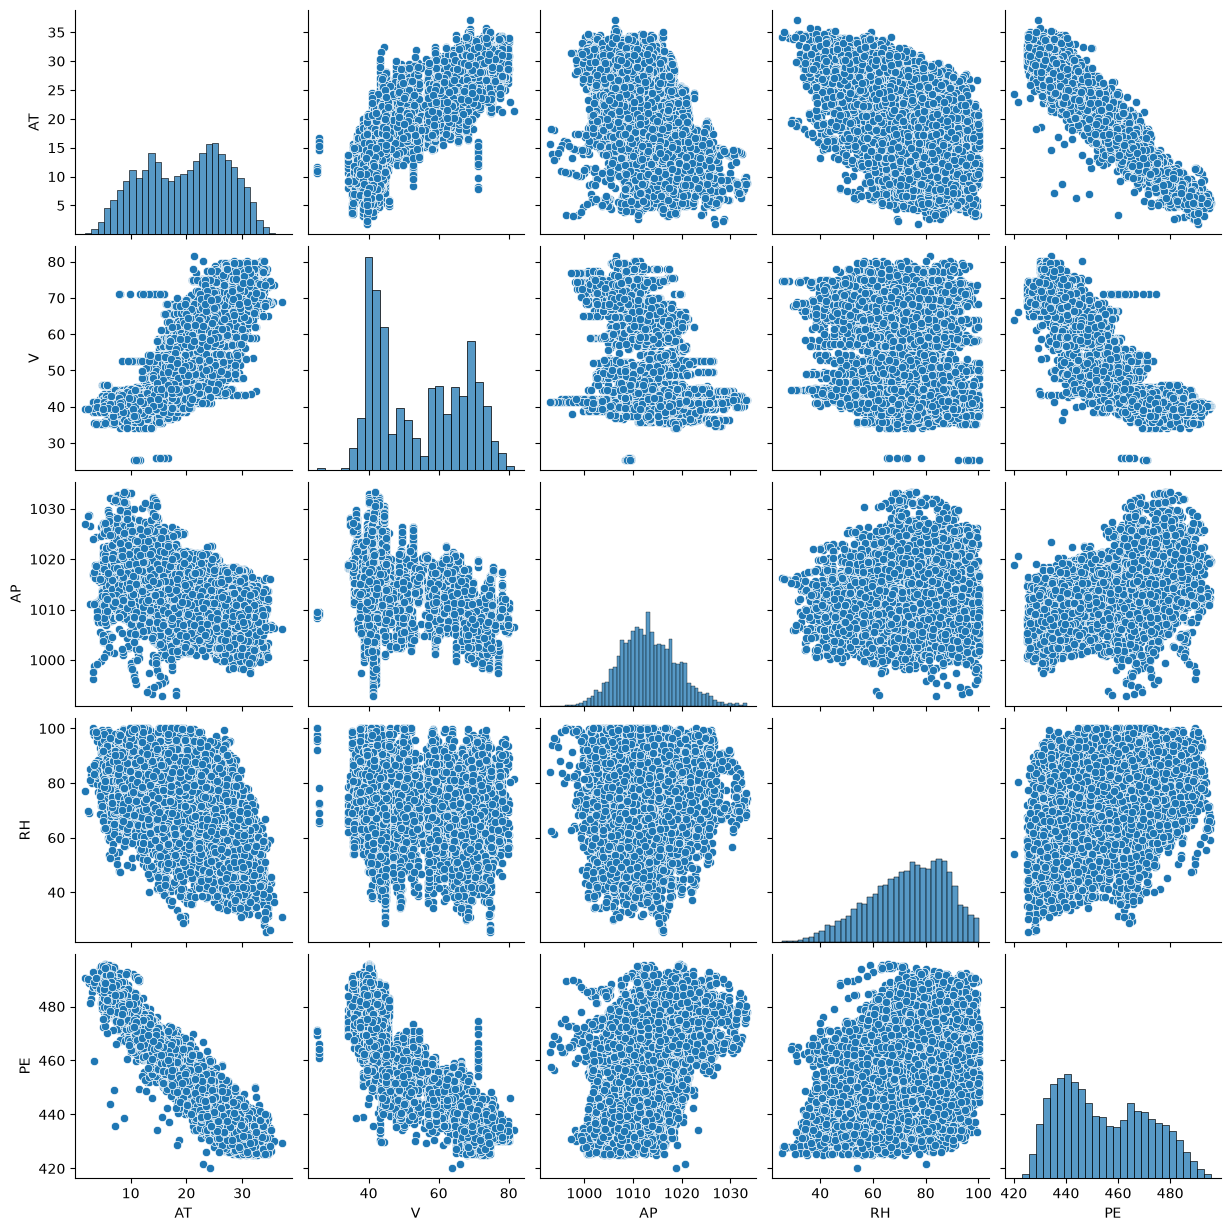

In [4]:
sns.pairplot(df)
plt.show()

Observations:

The pairwise scatterplots reveal several key patterns between the predictor variables and the target response:

Ambient Temperature (AT) displays a pronounced inverse relationship with PE, showing that power output consistently drops as ambient temperature rises.

Exhaust Vacuum (V) similarly exhibits a negative association with PE, albeit with more scatter than AT.

Conversely, Ambient Pressure (AP) demonstrates a modest positive linear trend with PE.

Relative Humidity (RH) shows only a subtle positive relationship with PE, pointing to a minimal individual impact on power output.

In summary, AT emerges as the primary driver of PE, followed closely by V, whereas AP and RH demonstrate much weaker linear influences.

Additionally, standard pairplots can lack clear distinction among data points when plotted without color mapping. Setting PE as the hue color-codes the observations by output level, offering a more nuanced visual understanding of how each predictor interacts with the response variable.

**iii. What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.**

In [5]:
# Calculate 1st and 3rd quartile for each column in the DataFrame

Quan1 = df.quantile(0.25)
Quan3 = df.quantile(0.75)

sum_table = pd.DataFrame({
    "MEAN": df.mean(),
    "MEDIAN": df.median(),
    "RANGE": df.max() - df.min(),
    "Q1": Quan1,
    "Q3": Quan3,
    "IQR": Quan3 - Quan1,
})
sum_table

,MEAN,MEDIAN,RANGE,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

For each predictor, fit a simple linear regression model to predict the response.
Describe your results. In which of the models is there a statistically significant
association between the predictor and the response? Create some plots to back
up your assertions. Are there any outliers that you would like to remove from
your data for each of these regression tasks?


REGRESSION MODEL: AT vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:50   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341    

MODEL,INTERCEPT (b0),SLOPE (b1),P-VALUE (b1),R-SQUARED
AT vs PE,497.034120,-2.171320,0.000000,0.898948


AT vs PE => STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = 0.0000)

DIRECTION: NEGATIVE RELATIONSHIP (SLOPE = -2.1713)

STRENGTH: STRONG LINEAR RELATIONSHIP (R-SQUARED = 0.8989)

INFLUENTIAL POINTS:  416

No Outliers to remove

These notable data points are just typical variations you expect when working with a large set of real-world data.



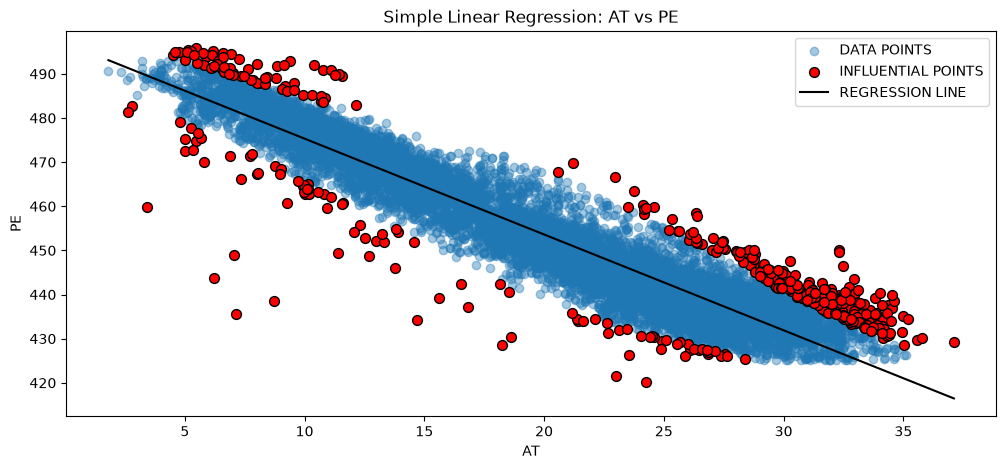

REGRESSION MODEL: V vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:51   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015     

MODEL,INTERCEPT (b0),SLOPE (b1),P-VALUE (b1),R-SQUARED
V vs PE,517.801526,-1.168135,0.000000,0.756518


V vs PE => STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = 0.0000)

DIRECTION: NEGATIVE RELATIONSHIP (SLOPE = -1.1681)

STRENGTH: STRONG LINEAR RELATIONSHIP (R-SQUARED = 0.7565)

INFLUENTIAL POINTS:  423

No Outliers to remove

These notable data points are just typical variations you expect when working with a large set of real-world data.



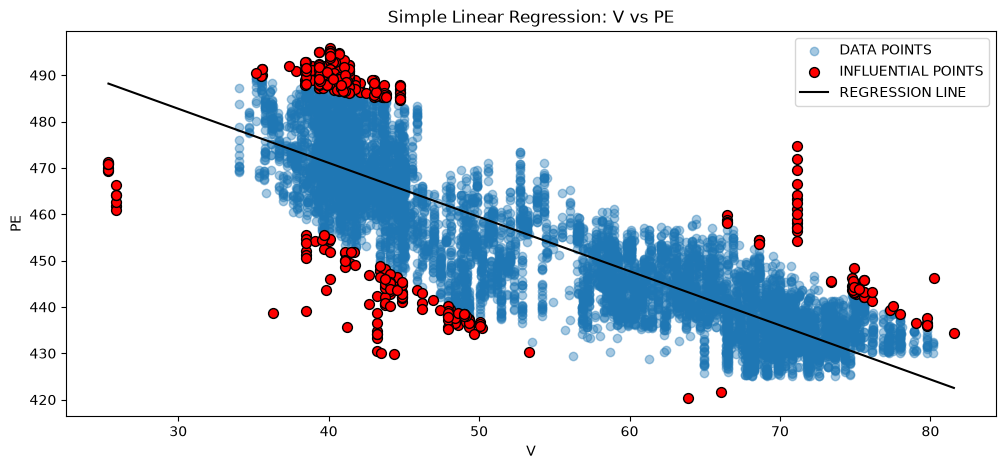

REGRESSION MODEL: AP vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:51   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610    

MODEL,INTERCEPT (b0),SLOPE (b1),P-VALUE (b1),R-SQUARED
AP vs PE,-1055.260989,1.489872,0.000000,0.268769


AP vs PE => STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = 0.0000)

DIRECTION: POSITIVE RELATIONSHIP (SLOPE = 1.4899)

STRENGTH: WEAK LINEAR RELATIONSHIP (R-SQUARED = 0.2688)

INFLUENTIAL POINTS:  300

No Outliers to remove

These notable data points are just typical variations you expect when working with a large set of real-world data.



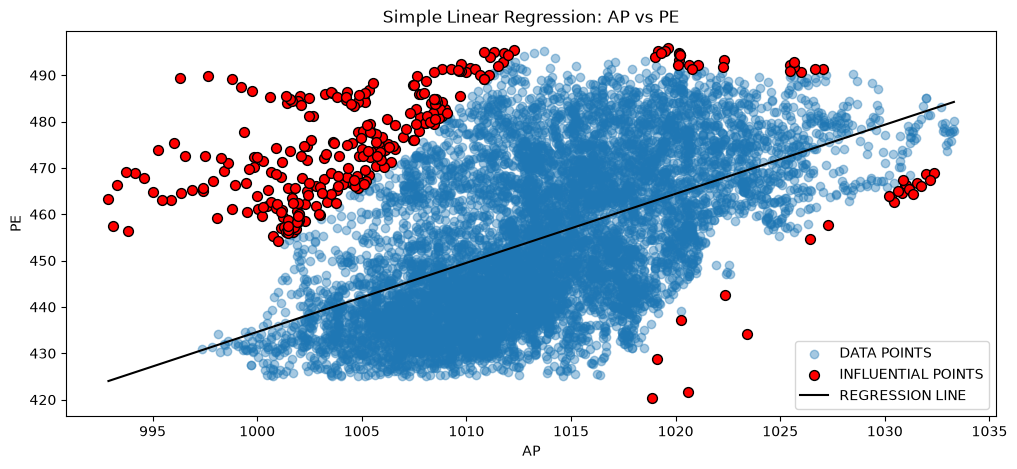

REGRESSION MODEL: RH vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:52   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618    

MODEL,INTERCEPT (b0),SLOPE (b1),P-VALUE (b1),R-SQUARED
RH vs PE,420.961766,0.455650,0.000000,0.151939


RH vs PE => STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = 0.0000)

DIRECTION: POSITIVE RELATIONSHIP (SLOPE = 0.4557)

STRENGTH: WEAK LINEAR RELATIONSHIP (R-SQUARED = 0.1519)

INFLUENTIAL POINTS:  249

No Outliers to remove

These notable data points are just typical variations you expect when working with a large set of real-world data.



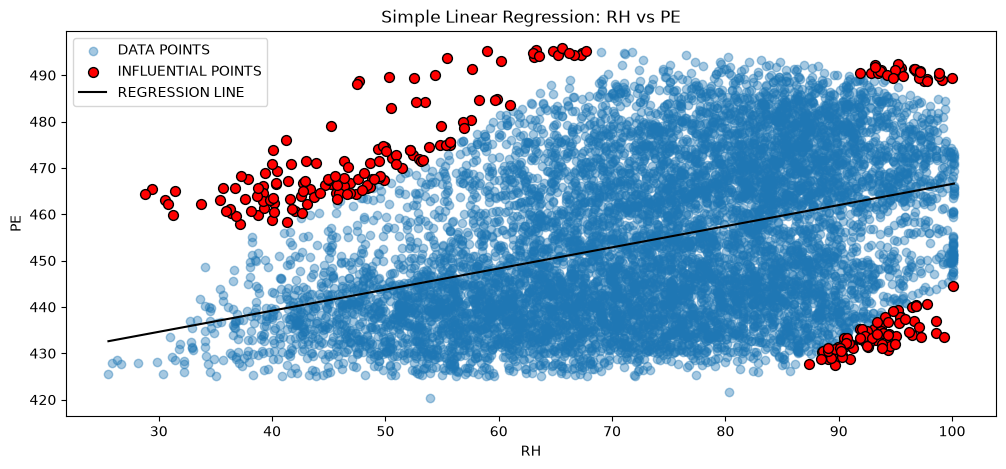

In [6]:
# Define predictor and target variables
pred = ["AT", "V", "AP", "RH"]
res = "PE"

# Set Cook's Distance threshold to identify influential data points
cook_thresh = 4/len(df)

sum_rows = []

# Iterating through each predictor variable to fit individual OLS models
for ite in pred:
    print(f"REGRESSION MODEL: {ite} vs {res}")
    
    # Add intercept to design matrix X and set target y
    X = sm.add_constant(df[[ite]])
    y = df[res]

    # Fit Simple Linear Regression model using Ordinary Least Squares (OLS)
    model = sm.OLS(y, X).fit()
    print(model.summary())

    print(f"{ite} vs {res} RESULTS:")
    
    # Create and display formatted table of model parameters
    row_df = pd.DataFrame({
        "MODEL": [f"{ite} vs {res}"],
        "INTERCEPT (b0)": [model.params["const"]],
        "SLOPE (b1)": [model.params[ite]],
        "P-VALUE (b1)": [model.pvalues[ite]],
        "R-SQUARED": [model.rsquared]
    }, )
    display(row_df.style.hide(axis="index"))
    
    # Test statistical significance based on p-value (alpha = 0.05) 
    pvalue = model.pvalues[ite]
    is_significant = False
    if pvalue < 0.05:
        is_significant = True
        print(f"{ite} vs {res} => STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = {pvalue:.4f})")
    else:
        print(f"{ite} vs {res} => NO STATISTICALLY SIGNIFICANT ASSOCIATION (p-value = {pvalue:.4f})")

    # Classify relationship direction based on slope sign
    direct = "NEGATIVE" if model.params[ite] < 0 else "POSITIVE"
    
    # Categorize model fit strength based on R-squared value
    r2 = model.rsquared
    if r2 >= 0.7:
        strength = "STRONG"
    elif r2 >= 0.3:
        strength = "MODERATE"
    else:
        strength = "WEAK"
    print(f"\nDIRECTION: {direct} RELATIONSHIP (SLOPE = {model.params[ite]:.4f})")
    print(f"\nSTRENGTH: {strength} LINEAR RELATIONSHIP (R-SQUARED = {model.rsquared:.4f})")

    # Cook's distance for influencial points
    influ = model.get_influence()
    cook_dis = influ.cooks_distance[0]
    influ_pts = df[cook_dis > cook_thresh]
    print(f"\nINFLUENTIAL POINTS: ", len(influ_pts))
    print("\nNo Outliers to remove\n")
    print("These notable data points are just typical variations you expect when working with a large set of real-world data.\n")

    # Generate analytical narrative based on strength classification
    if strength == "STRONG":
        analy = f"{ite} SHOWS A STRONG {direct.lower()} RELATIONSHIP WITH {res}, EXPLAINING A LARGE PORTION OF VARIABILITY."
    elif strength == "MODERATE":
        analy = f"{ite} HAS A MODERATE {direct.lower()} ASSOCIATION WITH {res}, INDICATING NOTICEABLE BUT LIMITED INFLUENCE."
    else:
        analy = f"{ite} EXHIBITS A WEAK {direct.lower()} RELATIONSHIP WITH {res}, SUGGESTING LIMITED PREDICTIVE POWER."

    # Append model metrics to summary table list
    sum_rows.append({
        "PREDICTOR": ite,
        "SLOPE": model.params[ite],
        "R²": r2,
        "P-VALUE": pvalue,
        "SIGNIFICANT?": is_significant,
        "DIRECTION": direct,
        "STRENTGH(R²)": strength,
        "INFLUENTIAL POINTS": len(influ_pts),
        "REMOVE OUTLIERS?": "No",
        "ANALYSIS": analy
    })
    
    plt.figure(figsize=(12,5))
    plt.scatter(df[ite], df[res], label="DATA POINTS", alpha=0.4)

    # Highlight influential points exceeding Cook's distance threshold
    if len(influ_pts) > 0:
        plt.scatter(influ_pts[ite], influ_pts[res], label="INFLUENTIAL POINTS", color="red", edgecolor="black", s=50)

    # Regression line (sorted)
    sort = np.argsort(df[ite].values)
    plt.plot(df[ite].values[sort], model.predict(X).values[sort], label="REGRESSION LINE", color = "black")
    plt.xlabel(ite)
    plt.ylabel(res)
    plt.title(f"Simple Linear Regression: {ite} vs {res}")
    plt.legend()
    plt.show()

In [7]:
resu = pd.DataFrame(sum_rows)
display(resu.style.hide(axis="index"))

PREDICTOR,SLOPE,R²,P-VALUE,SIGNIFICANT?,DIRECTION,STRENTGH(R²),INFLUENTIAL POINTS,REMOVE OUTLIERS?,ANALYSIS
AT,-2.171320,0.898948,0.000000,True,NEGATIVE,STRONG,416,No,"AT SHOWS A STRONG negative RELATIONSHIP WITH PE, EXPLAINING A LARGE PORTION OF VARIABILITY."
V,-1.168135,0.756518,0.000000,True,NEGATIVE,STRONG,423,No,"V SHOWS A STRONG negative RELATIONSHIP WITH PE, EXPLAINING A LARGE PORTION OF VARIABILITY."
AP,1.489872,0.268769,0.000000,True,POSITIVE,WEAK,300,No,"AP EXHIBITS A WEAK positive RELATIONSHIP WITH PE, SUGGESTING LIMITED PREDICTIVE POWER."
RH,0.455650,0.151939,0.000000,True,POSITIVE,WEAK,249,No,"RH EXHIBITS A WEAK positive RELATIONSHIP WITH PE, SUGGESTING LIMITED PREDICTIVE POWER."


### (d) Multiple Regression

Fit a multiple regression model to predict the response using all of the predictors.
Describe your results. For which predictors can we reject the null hypothesis
H0 : βj = 0?


In [8]:
pred = ["AT", "V", "AP", "RH"]
res = "PE"

print("MULTIPLE REGRESSION MODEL")


# Add a constant column for the intercept (beta_0) to the predictors matrix
X = sm.add_constant(df[pred])
y = df[res]

# Fit the Multiple Linear Regression model using Ordinary Least Squares
multi_mod = sm.OLS(y, X).fit()
print(multi_mod.summary())

MULTIPLE REGRESSION MODEL
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:52   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093     

In [9]:

print("H0 TEST RESULTS\n")

# Extract coefficients and p-values, excluding the constant term
coef = multi_mod.params.drop("const")
pvalue = multi_mod.pvalues.drop("const")

rej_mask = pvalue < 0.05
rej_list = list(pvalue[rej_mask].index)

# Build a formatted DataFrame summarizing p-values, coefficients, and H0 rejection status
hypot_df = pd.DataFrame({
    "PREDICTOR": coef.index,
    "P-VALUE": [f"{p:.3e}" for p in pvalue.values],
    "COEF": coef.values,
    "REJECT H0 (p < 0.05)?": ["YES" if p < 0.05 else "NO" for p in pvalue.values]
})

display(hypot_df.style.hide(axis="index"))

# Print final decision on H0 rejection based on p-value criteria
print("\nDECISION :: \n")
if len(rej_list) == 0:
    print("WE CANNOT REJECT H0 FOR ANY PREDICTOR.")
else:
    print(f"WE CAN REJECT H0 fOR: {', '.join(rej_list)}.")

# Print key statistical observations from the model
print("\nOBSERVATIONS :: \n")
print(f"R-SQUARED = {multi_mod.rsquared:.4f} (HIGH VALUE) - MULTIPLE REGRESSION MODEL (AT, V, AP, RH) EXPLAINS HIGH VARIABILITY IN PE")

# Loop through each predictor to output its marginal effect on PE
for ite in pred:
    sign = "INCREASES" if coef[ite] > 0 else "DECREASES"
    print(f"HOLDING OTHER VARIABLES CONSTANT, 1 UNIT INCREASE IN {ite} {sign} PE BY {coef[ite]:.4f} ON AVERAGE.")

print("ALL PREDICTORS HAVE P-VALUES LESS THAN 0.05. SO, WE REJECT THE NULL HYPOTHESIS H0 FOR ALL PREDICTORS.")

H0 TEST RESULTS



PREDICTOR,P-VALUE,COEF,REJECT H0 (p < 0.05)?
AT,0.000e+00,-1.977513,YES
V,4.375e-215,-0.233916,YES
AP,5.507e-11,0.062083,YES
RH,3.105e-293,-0.158054,YES



DECISION :: 

WE CAN REJECT H0 fOR: AT, V, AP, RH.

OBSERVATIONS :: 

R-SQUARED = 0.9287 (HIGH VALUE) - MULTIPLE REGRESSION MODEL (AT, V, AP, RH) EXPLAINS HIGH VARIABILITY IN PE
HOLDING OTHER VARIABLES CONSTANT, 1 UNIT INCREASE IN AT DECREASES PE BY -1.9775 ON AVERAGE.
HOLDING OTHER VARIABLES CONSTANT, 1 UNIT INCREASE IN V DECREASES PE BY -0.2339 ON AVERAGE.
HOLDING OTHER VARIABLES CONSTANT, 1 UNIT INCREASE IN AP INCREASES PE BY 0.0621 ON AVERAGE.
HOLDING OTHER VARIABLES CONSTANT, 1 UNIT INCREASE IN RH DECREASES PE BY -0.1581 ON AVERAGE.
ALL PREDICTORS HAVE P-VALUES LESS THAN 0.05. SO, WE REJECT THE NULL HYPOTHESIS H0 FOR ALL PREDICTORS.


**(e) How do your results from 1c compare to your results from 1d?**

**Create a plot displaying the univariate regression coeﬃcients from 1c on the x-axis, and the multiple regression coeﬃcients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coeﬃcient in a simple linear regression model is shown on the x-axis, and its coeﬃcient estimate in the multiple linear regression model is shown on the y-axis.**

PREDICTOR,SIMPLE COEF,MULTIPLE COEF
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


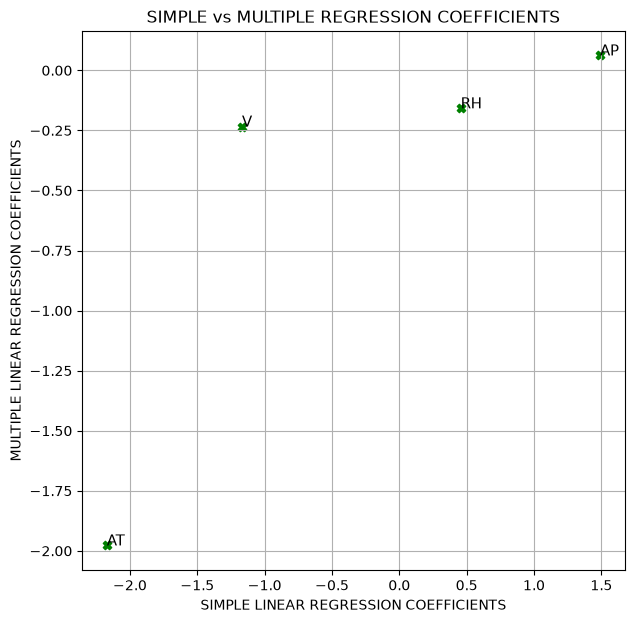

In [10]:
simple_coef = []

# Fit simple linear regression models individually for each predictor variable
for ite in pred:
    X = sm.add_constant(df[[ite]])
    y = df[res]

    model = sm.OLS(y, X).fit()     # Fit Ordinary Least Squares model
    simple_coef.append(model.params[ite])    # Extract and store slope coefficient

# Extract multiple linear regression slope coefficients (excluding intercept)
multi_coef = multi_mod.params.drop("const")

# Create comparison DataFrame of univariate vs. multiple regression coefficients
slope_df = pd.DataFrame({
    "PREDICTOR": multi_coef.index,
    "SIMPLE COEF": simple_coef,
    "MULTIPLE COEF": multi_coef.values
})
display(slope_df.style.hide(axis="index"))

plt.figure(figsize=(7,7))

# Define axis values and point annotations
x_value = slope_df["SIMPLE COEF"]
y_value = slope_df["MULTIPLE COEF"]
labels = slope_df["PREDICTOR"]

# Annotate each point on the plot with its respective predictor name
plt.scatter(x_value, y_value, marker='X', color='green')
for a, b, label in zip(x_value, y_value, labels):
    plt.text(a, b, label, fontsize=11)

# Format plot labels, title, and grid
plt.xlabel("SIMPLE LINEAR REGRESSION COEFFICIENTS")
plt.ylabel("MULTIPLE LINEAR REGRESSION COEFFICIENTS")
plt.title("SIMPLE vs MULTIPLE REGRESSION COEFFICIENTS")
plt.grid(True)
plt.show()

### (f) Nonlinear Association

Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form Y = β0 + β1X + β2X^2 + β3X^3 + e**

In [11]:
pred = ["AT", "V", "AP", "RH"]
res = "PE"

poly_r = []

# Iterate through each predictor variable to fit cubic polynomial models
for ite in pred:
    print(f"NON LINEAR REGRESSION MODEL: {ite} vs {res}")

    # Create feature matrix with linear, quadratic, and cubic terms
    X_poly = pd.DataFrame()
    X_poly[ite] = df[ite]
    X_poly[f"{ite}²"] = df[ite] ** 2
    X_poly[f"{ite}³"] = df[ite] ** 3

    X_poly = sm.add_constant(X_poly)
    y = df[res]

    # Fit Ordinary Least Squares (OLS) polynomial regression model
    poly_mod = sm.OLS(y, X_poly).fit()
    print(poly_mod.summary())
    
    p_quad = poly_mod.pvalues[f"{ite}²"]
    p_cub = poly_mod.pvalues[f"{ite}³"]

    print("\nNON LINEARITY CHECK:")

    # Determine significance of non-linear association (alpha = 0.05)
    nonlin = False
    if p_quad < 0.05 or p_cub < 0.05:
        nonlin = True
        print("EVIDENCE OF NONLINEAR ASSOCIATION DETECTED.\n")
    else:
        print("NO STRONG EVIDENCE OF NONLINEAR ASSOCIATION.\n")

    # Append model parameters and metrics to summary list
    poly_r.append({
        "PREDICTOR": ite,
        "QUADRATIC P-VALUE": f"{p_quad:.3e}",
        "CUBIC P-VALUE": f"{p_cub:.3e}",
        "NON LINEAR ASSOCIATION?": nonlin,
        "POLYNOMIAL R²": poly_mod.rsquared
    })

poly_df = pd.DataFrame(poly_r)
display(poly_df.style.hide(axis="index"))

NON LINEAR REGRESSION MODEL: AT vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:53   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        4

PREDICTOR,QUADRATIC P-VALUE,CUBIC P-VALUE,NON LINEAR ASSOCIATION?,POLYNOMIAL R²
AT,8.833e-73,3.652e-110,True,0.911883
V,7.685e-01,1.373e-02,True,0.775022
AP,3.667e-17,8.264e-18,True,0.274863
RH,9.395e-06,1.440e-05,True,0.153743


### (g) Interactions of Predictors

Is there evidence of association of interactions of predictors with the response? To
answer this question, run a full linear regression model with all pairwise interaction
terms and state whether any interaction terms are statistically significant.

In [12]:
pred = ["AT", "V", "AP", "RH"]
res = "PE"

X = df[pred].copy()

# Generate all unique pairwise interaction terms between predictors
interact_terms = []
for i in range(len(pred)):
    for j in range(i + 1, len(pred)):
        name = f"{pred[i]} × {pred[j]}"
        X[name] = df[pred[i]] * df[pred[j]]
        interact_terms.append(name)

# Add constant term (intercept) and extract target vector y
X = sm.add_constant(X)
y = df[res]

# Fit Ordinary Least Squares (OLS) model with main effects and interaction terms
interact_model = sm.OLS(y, X).fit()
print(interact_model.summary())

print("\nINTERACTION TERM\n")

pvalue_inter = interact_model.pvalues[interact_terms]

# Build summary DataFrame evaluating statistical significance of interaction terms
int_df = pd.DataFrame({
    "INTERACTION TERM": interact_terms,
    "P-VALUE": [f"{p:.3e}" for p in pvalue_inter.values],
    f"Statistically Significant (p < 0.05)?": ["YES" if p < 0.05 else "NO" for p in pvalue_inter.values]
})

display(int_df.style.hide(axis="index"))

# Identify interaction terms meeting the p < 0.05 significance threshold
sig_term = [t for t in interact_terms if pvalue_inter[t] < 0.05]

# Print final decision summarizing significant interaction effects
print("\nDEICSION ::")
if len(sig_term) == 0:
    print("NO PAIRWISE INTERACTION TERMS ARE STATISTICALLY SIGNIFICANT.")
else:
    print("STATISTICALLY SIGNIFICANT INTERACTION TERMS.")
    print(", ".join(sig_term))

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:53   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

INTERACTION TERM,P-VALUE,Statistically Significant (p < 0.05)?
AT × V,3.333e-117,YES
AT × AP,4.521e-01,NO
AT × RH,1.217e-10,YES
V × AP,2.877e-07,YES
V × RH,8.619e-02,NO
AP × RH,3.361e-02,YES



DEICSION ::
STATISTICALLY SIGNIFICANT INTERACTION TERMS.
AT × V, AT × RH, V × AP, AP × RH


**(h) Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response? Train the regression model on a
randomly selected 70% subset of the data with all predictors. Also, run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values (be careful about interaction
terms). Test both models on the remaining points and report your train and test MSEs.**

In [13]:
pred = ["AT", "V", "AP", "RH"]
res = "PE"
alpha = 0.05

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

y_train = train_df[res]
y_test = test_df[res]

print("\n1. BASIC LINEAR REGRESSION \n")

# Add constant intercept term to training design matrix
X_train1 = sm.add_constant(train_df[pred])
mod_1 = sm.OLS(y_train, X_train1).fit()

# Add constant intercept term to testing design matrix
X_test1 = sm.add_constant(test_df[pred])

train_pred1 = mod_1.predict(X_train1)
test_pred1 = mod_1.predict(X_test1)

# Calculate Mean Squared Error (MSE) for train and test predictions
train_mse1 = mean_squared_error(y_train, train_pred1)
test_mse1 = mean_squared_error(y_test, test_pred1)

print(f"Train MSE: {train_mse1:.5f}")
print(f"Test MSE: {test_mse1:.5f}")

print("\n 2. QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION \n")

X_train2 = train_df[pred].copy()

# Add quadratic terms (X^2) for all predictors
quad_ter = []
for ite in pred:
    q_name = f"{ite}^2"
    X_train2[q_name] = train_df[ite] ** 2
    quad_ter.append(q_name)

# Add all pairwise interaction terms (X1 * X2)
interact_terms = []
for i in range(len(pred)):
    for j in range(i + 1, len(pred)):
        name = f"{pred[i]} × {pred[j]}"
        X_train2[name] = train_df[pred[i]] * train_df[pred[j]]
        interact_terms.append(name)

# Add intercept term and fit full quadratic/interaction model
X_train2 = sm.add_constant(X_train2)
mod_2 = sm.OLS(y_train, X_train2).fit()
print(mod_2.summary())

X_test2 = test_df[pred].copy()

for ite in pred:
    X_test2[f"{ite}^2"] = test_df[ite] ** 2

for i in range(len(pred)):
    for j in range(i + 1, len(pred)):
        name = f"{pred[i]} × {pred[j]}"
        X_test2[name] = test_df[pred[i]] * test_df[pred[j]]

X_test2 = sm.add_constant(X_test2)

# Predict response values and compute train/test MSEs for Model 2
train_pred2 = mod_2.predict(X_train2)
test_pred2 = mod_2.predict(X_test2)

train_mse2 = mean_squared_error(y_train, train_pred2)
test_mse2 = mean_squared_error(y_test, test_pred2)

print("\n TRAIN||TEST MSE\n")

print(f"Train MSE: {train_mse2:.5f}")
print(f"Test MSE: {test_mse2:.5f}")

print("\n 3. REDUCED QUADRATIC + INTERACTION REGRESSION \n")

# Fit full model to extract p-values (fixing variable name to X_train2)
full_mod_3 = sm.OLS(y_train, X_train2).fit()

# Select statistically significant predictors based on p-value < alpha
significant_vars = full_mod_3.pvalues[full_mod_3.pvalues < alpha].index
significant_vars = [v for v in significant_vars if v != "const"]

print("STATISTICALLY SIGNIFICANT VARIABLES")
print(", ".join(significant_vars))

# Subset train and test feature matrices to include only significant terms
X_train3 = X_train2[["const"] + significant_vars]
mod_3 = sm.OLS(y_train, X_train3).fit()
print(mod_3.summary())

X_test3 = X_test2[["const"] + significant_vars]

train_pred3 = mod_3.predict(X_train3)
test_pred3 = mod_3.predict(X_test3)

train_mse3 = mean_squared_error(y_train, train_pred3)
test_mse3 = mean_squared_error(y_test, test_pred3)

print("\n TRAIN||TEST MSE\n")
print(f"Train MSE: {train_mse3:.5f}")
print(f"Test MSE: {test_mse3:.5f}")


1. BASIC LINEAR REGRESSION 

Train MSE: 20.58084
Test MSE: 21.23986

 2. QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION 

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:57:53   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------

In [14]:
# Constructing a comparison DataFrame summarizing Train and Test MSE across all three regression models
res_df = pd.DataFrame({
    "Model": [
        "MODEL 1 = LINEAR REGRESSION",
        "MODEL 2 = QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION",
        "MODEL 3 = REDUCED QUADRATIC + INTERACTION REGRESSION"
    ],
    "Train MSE": [
        train_mse1,
        train_mse2,
        train_mse3
    ],
    "Test MSE": [
        test_mse1,
        test_mse2,
        test_mse3
    ]
})
display(res_df.style.hide(axis="index"))

Model,Train MSE,Test MSE
MODEL 1 = LINEAR REGRESSION,20.580840,21.239857
MODEL 2 = QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION,17.887800,18.647312
MODEL 3 = REDUCED QUADRATIC + INTERACTION REGRESSION,18.457177,19.221019


### (i) KNN

Perform k-nearest neighbor regression for this dataset using both normalized
and raw features. Find the value of k ∈ {1, 2, . . . , 100} that gives you the
best fit. Plot the train and test errors in terms of 1/k.


RAW - BEST K:  5
RAW - TRAIN MSE AT BEST K :  10.60077
RAW - TEST MSE AT BEST K  15.72682

NORMALISED - BEST K:  4
NORMALISED - TRAIN MSE AT BEST K  8.59143
NORMALISED - TEST MSE AT BEST K 14.30567


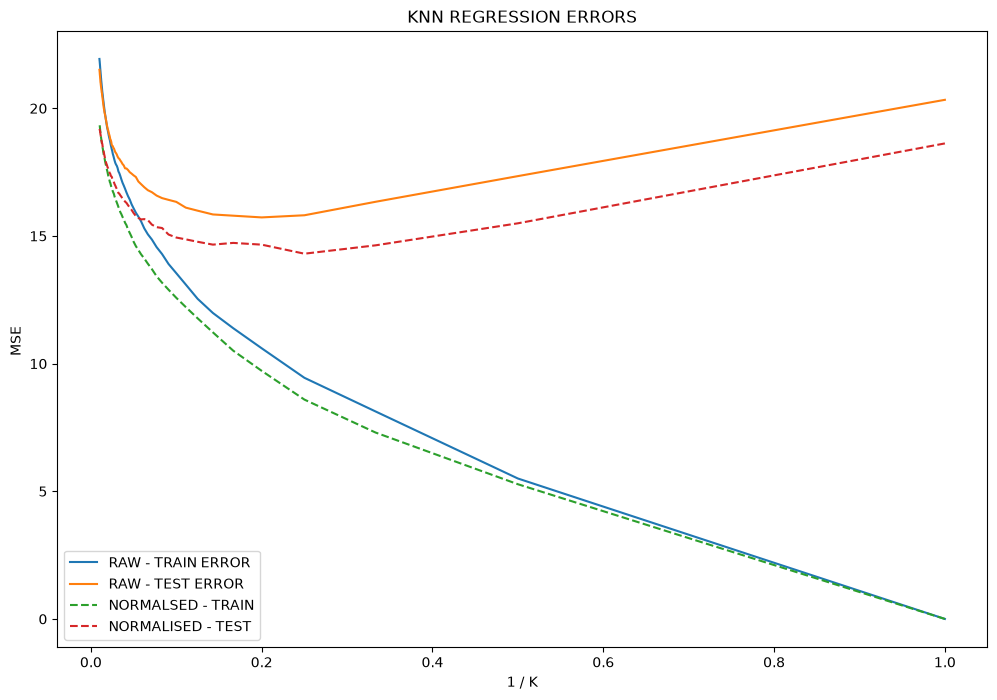

In [15]:
pred = ["AT", "V", "AP", "RH"]
res = "PE"

X_train = train_df[pred]
X_test  = test_df[pred]

y_train = train_df[res]
y_test  = test_df[res]

kn_list = list(range(1, 101))

train_err_raw = []
test_err_raw = []

train_err_norm = []
test_err_norm = []

# Evaluate KNN Regression models across K values using raw features
for ite in kn_list:
    model = KNeighborsRegressor(n_neighbors=ite)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_err_raw.append(mean_squared_error(y_train, train_pred))
    test_err_raw.append(mean_squared_error(y_test, test_pred))

# Standardize feature matrices using z-score normalization
scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train)
X_test_scale  = scale.transform(X_test)

# Evaluate KNN Regression models across K values using normalized features
for ite in kn_list:
    model = KNeighborsRegressor(n_neighbors=ite)
    model.fit(X_train_scale, y_train)

    train_pred = model.predict(X_train_scale)
    test_pred  = model.predict(X_test_scale)

    train_err_norm.append(mean_squared_error(y_train, train_pred))
    test_err_norm.append(mean_squared_error(y_test, test_pred))

# Find index and optimal K value yielding lowest test MSE for both approaches
best_idx_raw = int(np.argmin(test_err_raw))
best_idx_norm = int(np.argmin(test_err_norm))

best_k_raw = kn_list[best_idx_raw]
best_k_norm = kn_list[best_idx_norm]

# Display optimal and normalizedperformance metrics for raw features
print("RAW - BEST K: ", best_k_raw)
print("RAW - TRAIN MSE AT BEST K : ", round(train_err_raw[best_idx_raw], 5))
print("RAW - TEST MSE AT BEST K ", round(test_err_raw[best_idx_raw], 5))

print("\nNORMALISED - BEST K: ", best_k_norm)
print("NORMALISED - TRAIN MSE AT BEST K ", round(train_err_norm[best_idx_norm], 5))
print("NORMALISED - TEST MSE AT BEST K", round(test_err_norm[best_idx_norm], 5))

# Plot training and test MSE curves against model flexibility (1/K)
plt.figure(figsize=(12,8))

inv_kn = [1/ite for ite in kn_list]

plt.plot(inv_kn, train_err_raw, label="RAW - TRAIN ERROR")
plt.plot(inv_kn, test_err_raw, label="RAW - TEST ERROR")

plt.plot(inv_kn, train_err_norm, linestyle="--", label="NORMALSED - TRAIN")
plt.plot(inv_kn, test_err_norm, linestyle="--", label="NORMALISED - TEST")

plt.xlabel("1 / K")
plt.ylabel("MSE ")
plt.title("KNN REGRESSION ERRORS")
plt.legend()
plt.show()

**(j) Compare the results of KNN Regression with the linear regression model that has the smallest test error and provide your analysis.**

In [16]:
best_index_raw = np.argmin(test_err_raw)
best_index_norm = np.argmin(test_err_norm)

comparison_df = pd.DataFrame({
    "MODEL": [
        "MODEL 1 = LINEAR REGRESSION",
        "MODEL 2 = QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION",
        "MODEL 3 = REDUCED QUADRATIC + INTERACTION REGRESSION",
        "MODEL 4 = RAW FEATURES = KNN REGRESSION",
        "MODEL 5 = NORMALIZED FEATURES = KNN REGRESSION"
    ],
    "BEST K": [
        "-",
        "-",
        "-",
        kn_list[best_index_raw],
        kn_list[best_index_norm]
    ],
    "TRAIN MSE": [
        train_mse1,
        train_mse2,
        train_mse3,
        train_err_raw[best_index_raw],
        train_err_norm[best_index_norm]
    ],
    "TEST MSE": [
        test_mse1,
        test_mse2,
        test_mse3,
        test_err_raw[best_index_raw],
        test_err_norm[best_index_norm]
    ]
})

display(comparison_df.style.hide(axis="index"))

MODEL,BEST K,TRAIN MSE,TEST MSE
MODEL 1 = LINEAR REGRESSION,-,20.580840,21.239857
MODEL 2 = QUADRATIC + ALL PAIRWISE INTERACTIONS REGRESSION,-,17.887800,18.647312
MODEL 3 = REDUCED QUADRATIC + INTERACTION REGRESSION,-,18.457177,19.221019
MODEL 4 = RAW FEATURES = KNN REGRESSION,5,10.600769,15.726820
MODEL 5 = NORMALIZED FEATURES = KNN REGRESSION,4,8.591433,14.305669


Analysis : 

Model 2 (Quadratic + Interaction Regression) outperforms the standard linear regression model, demonstrating that accounting for non-linear dynamics enhances predictive precision. Meanwhile, Model 3 (Reduced Model) yields comparable results using fewer predictors, indicating that eliminating statistically insignificant terms preserves model performance while streamlining complexity.

When compared to linear regression models, both KNN regression variations achieve lower test MSE values. This highlights that the relationship between the predictor variables and target output (PE) possesses non-linear characteristics that non-parametric methods capture more effectively.

Among the non-parametric models, KNN trained on standardized features achieves the lowest overall test MSE, underscoring the importance of feature scaling when calculating distance metrics.

Ultimately, KNN Regression with normalized features delivers the highest predictive accuracy across all evaluations, though parametric linear models retain value due to their interpretability in quantifying individual feature effects.

# 2. ISLR 2.4.1

**For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.**

**(a) The sample size n is extremely large, and the number of predictors p is small.**

A flexible method will perform better. With a large volume of observations relative to a small feature set, model variance is significantly reduced. This allows a complex model to accurately capture the underlying structure without a high risk of overfitting.

**(b) The number of predictors p is extremely large, and the number of observations n is small.** 

An inflexible method will perform better. In high-dimensional, small-sample regimes, flexible models are prone to severe overfitting and high variance. A simpler model limits flexibility, helping stabilize predictions and control variance despite sparse data.

**(c) The relationship between the predictors and response is highly non-linear.** 

A flexible method will perform better. Inflexible models enforce restrictive assumptions (such as linearity) that fail to capture intricate patterns, leading to high bias. Flexible approaches adapt to complex non-linear curves, substantially reducing bias.

**(d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely high.**

An inflexible method will perform better. High irreducible error introduces heavy noise into the dataset. Highly flexible models risk fitting this random noise rather than the signal, whereas restrictive models resist overfitting noise and provide more reliable estimates.

# 3. ISLR: 2.4.7

**The table below provides a training data set containing six observations, three predictors, and one qualitative response variable. Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.**
| Obs |  X1  |  X2  |  X3  |   Y   |
|-----|------|------|------|-------|
|  1  |  0   |  3   |  0   |  Red  |
|  2  |  2   |  0   |  0   |  Red  |
|  3  |  0   |  1   |  3   |  Red  |
|  4  |  0   |  1   |  2   | Green |
|  5  | -1   |  0   |  1   | Green |
|  6  |  1   |  1   |  1   |  Red  |

**a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.**

Euclidean Distance Formula = **sqrt((X1-0)^2 + (X2-0)^2 + (X3-0)^2)**

| Obs | X1 | X2 | X3 | Euclidean Distance                        |
|-----|----|----|----|-------------------------------------------|
| 1   | 0  | 3  | 0  | sqrt((0-0)^2 + (3-0)^2 + (0-0)^2) = 3     |
| 2   | 2  | 0  | 0  | sqrt((2-0)^2 + (0-0)^2 + (0-0)^2) = 2     |
| 3   | 0  | 1  | 3  | sqrt((0-0)^2 + (1-0)^2 + (3-0)^2) = 3.162 |
| 4   | 0  | 1  | 2  | sqrt((0-0)^2 + (1-0)^2 + (2-0)^2) = 2.23  |
| 5   | -1 | 0  | 1  | sqrt((-1-0)^2 + (0-0)^2 + (1-0)^2) = 1.414|
| 6   | 1  | 1  | 1  | sqrt((1-1)^2 + (1-0)^2 + (1-0)^2) = 1.732 |

**b) What is our prediction with K = 1? Why?**

**Prediction for K = 1:**

Reasoning: With $K = 1$, the model considers only the single nearest neighbor to the test point. Observation 5 is closest, having the minimum Euclidean distance of $1.414$. Because Observation 5 belongs to class Green, the test point is assigned to Green.

**c) What is our prediction with K = 3? Why?**

**Prediction for K = 3:**

Prediction: RedReasoning: With $K = 3$, the model evaluates the three nearest neighbors based on distance:Observation 5 ($d = 1.414$) – GreenObservation 6 ($d = 1.732$) – RedObservation 2 ($d = 2.000$) – RedVote Breakdown: 2 Red vs. 1 Green. Since Red holds the majority vote, the test point is classified as Red.


**d) If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for K to be large or small? Why?**

**Expected K value for Nonlinear Decision Boundary: Small**

A highly non-linear decision boundary requires a flexible model to accurately follow complex, non-linear patterns. Selecting a small $K$ allows the decision surface to remain highly flexible. Conversely, a large $K$ forces the boundary to become overly smooth and linear, leading to high bias and poor performance on intricate boundaries.

### REFERENCES

- https://medium.com/@Adekola_Olawale/dealing-with-outliers-in-machine-learning-af09b5ce6aa2
- https://medium.com/@nandiniverma78988/understanding-k-nearest-neighbors-knn-regression-in-machine-learning-c751a7cf516c
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- https://www.w3schools.com/datascience/ds_linear_regression_rsquared.asp
- https://medium.com/@Adekola_Olawale/dealing-with-outliers-in-machine-learning-af09b5ce6aa2

**AI PROMPTS**

How can hypothesis testing be used to identify which independent variables are statistically significant in a multiple linear regression analysis?

How do you format and display comparative model performance metrics in structured tables using pandas?

How can polynomial features (quadratic terms) and interaction effects be incorporated into a linear model, and how do you evaluate performance by comparing training and test Mean Squared Error (MSE)?

How is Cook’s Distance calculated to pinpoint influential data points, and what criteria determine if those points should be excluded from the dataset?